# Flight Price Prediction Using Machine Learning
#### OBJECTIVE: 
##### To predict flight ticket prices based on features such as airline, source, destination, duration, stops, and journey details using regression models.

#### MODELS USED:
###### --> Linear Regression
###### --> Decision Tree Regressor
###### --> Random Forest Regressor
###### --> XGBoost Regressor

In [1]:
## Importing of Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the Dataset...
data=pd.read_excel("Flight_Fare.xlsx")

In [3]:
## Dataset overview...
data.head()                 

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
# Checking for NULL Values...
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [6]:
# To know the total no.of rows and columns in the entire dataset...
data.shape

(10683, 11)

In [7]:
# Dropping the records that has NULL values 
data.dropna(inplace=True)              

In [8]:
# Checking whether the NULL values are removed or not...
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [9]:
data.shape

(10682, 11)

In [10]:
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [11]:
# Check for Duplicate Values...
data.duplicated().sum()

np.int64(220)

In [12]:
# Removing of Duplicate records 
data.drop_duplicates(inplace=True)         

In [13]:
# Checking whether the duplicate records are removed or not...
data.duplicated().sum()        

np.int64(0)

In [14]:
data.describe()

,Price
count,10462.000000
mean,9026.790289
std,4624.849541
min,1759.000000
25%,5224.000000
50%,8266.000000
75%,12344.750000
max,79512.000000


In [15]:
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Date_of_Journey  10462 non-null  object
 2   Source           10462 non-null  object
 3   Destination      10462 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10462 non-null  object
 6   Arrival_Time     10462 non-null  object
 7   Duration         10462 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10462 non-null  object
 10  Price            10462 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 980.8+ KB


## FEATURE ENGINEERING

In [17]:
# Removing unnecessary columns..
data.drop(["Route", "Additional_Info"], axis=1, inplace=True)

##### ---> The Route column was dropped because it was redundant, as the same information was already captured by Source, Destination, and Total_Stops. 
##### ---> The Additional_Info column was removed because it had very low variance, with most values being “No info”, making it less useful for prediction.

In [18]:
data.shape

(10462, 9)

In [19]:
# Date of Journey----->Converting it into journey day and journey month columns... 
data['Date_of_Journey'] = pd.to_datetime(data['Date_of_Journey'], dayfirst=True)
data['Journey_day'] = data['Date_of_Journey'].dt.day
data['Journey_month'] = data['Date_of_Journey'].dt.month
data.drop('Date_of_Journey', axis=1, inplace=True)

In [20]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Dep_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Price', 'Journey_day', 'Journey_month'],
      dtype='object')

In [21]:
# Dep_Time----->Converting it into Dep_hour and Dep_min
data["Dep_hour"] = pd.to_datetime(data["Dep_Time"]).dt.hour
data["Dep_min"] = pd.to_datetime(data["Dep_Time"]).dt.minute
data.drop(["Dep_Time"], axis=1, inplace=True)

In [22]:
data.head()

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min
0,IndiGo,Banglore,New Delhi,01:10 22 Mar,2h 50m,non-stop,3897,24,3,22,20
1,Air India,Kolkata,Banglore,13:15,7h 25m,2 stops,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,04:25 10 Jun,19h,2 stops,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1 stop,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,21:35,4h 45m,1 stop,13302,1,3,16,50


In [23]:
data.shape

(10462, 11)

In [24]:
# Arrival_Time------> Converting it into Arrival_Hour and Arrival_min...
data["Arrival_hour"] = pd.to_datetime(data["Arrival_Time"]).dt.hour
data["Arrival_min"] = pd.to_datetime(data["Arrival_Time"]).dt.minute
data.drop(["Arrival_Time"], axis=1, inplace=True)

In [25]:
data.shape

(10462, 12)

In [26]:
data.head()

,Airline,Source,Destination,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,2h 50m,non-stop,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2 stops,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,19h,2 stops,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1 stop,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,4h 45m,1 stop,13302,1,3,16,50,21,35


In [27]:
data.isnull().sum()

Airline          0
Source           0
Destination      0
Duration         0
Total_Stops      0
Price            0
Journey_day      0
Journey_month    0
Dep_hour         0
Dep_min          0
Arrival_hour     0
Arrival_min      0
dtype: int64

In [28]:
###--> Converting Duration column to hours and mins columns... and then combining those two columns to a single column "Duration_mins"....
duration = data["Duration"]

hours = duration.str.extract('(\d+)h').astype(float).fillna(0)
mins = duration.str.extract('(\d+)m').astype(float).fillna(0)

data["Duration_mins"] = hours*60 + mins
data.drop("Duration", axis=1, inplace=True)

In [29]:
data.shape

(10462, 12)

In [30]:
data

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_mins
0,IndiGo,Banglore,New Delhi,non-stop,3897,24,3,22,20,1,10,170.0
1,Air India,Kolkata,Banglore,2 stops,7662,1,5,5,50,13,15,445.0
2,Jet Airways,Delhi,Cochin,2 stops,13882,9,6,9,25,4,25,1140.0
3,IndiGo,Kolkata,Banglore,1 stop,6218,12,5,18,5,23,30,325.0
4,IndiGo,Banglore,New Delhi,1 stop,13302,1,3,16,50,21,35,285.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,4107,9,4,19,55,22,25,150.0
10679,Air India,Kolkata,Banglore,non-stop,4145,27,4,20,45,23,20,155.0
10680,Jet Airways,Banglore,Delhi,non-stop,7229,27,4,8,20,11,20,180.0
10681,Vistara,Banglore,New Delhi,non-stop,12648,1,3,11,30,14,10,160.0


In [31]:
# Total_Stops ------> making it into numerical values...
data.replace({"non-stop":0, "1 stop":1, "2 stops":2, "3 stops":3, "4 stops":4}, inplace=True)

In [32]:
data

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_mins
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,170.0
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,445.0
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,25,1140.0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,30,325.0
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,35,285.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,4107,9,4,19,55,22,25,150.0
10679,Air India,Kolkata,Banglore,0,4145,27,4,20,45,23,20,155.0
10680,Jet Airways,Banglore,Delhi,0,7229,27,4,8,20,11,20,180.0
10681,Vistara,Banglore,New Delhi,0,12648,1,3,11,30,14,10,160.0


#### Outliers 

In [33]:
num_cols = [
    "Price",
    "Total_Stops",
    "Journey_day",
    "Journey_month",
    "Dep_hour",
    "Dep_min",
    "Arrival_hour",
    "Arrival_min",
    "Duration_mins"
]

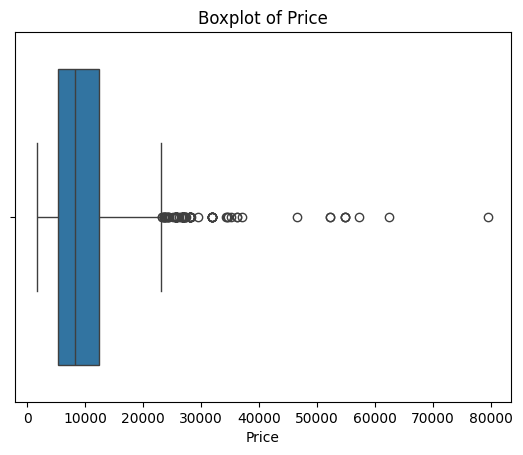

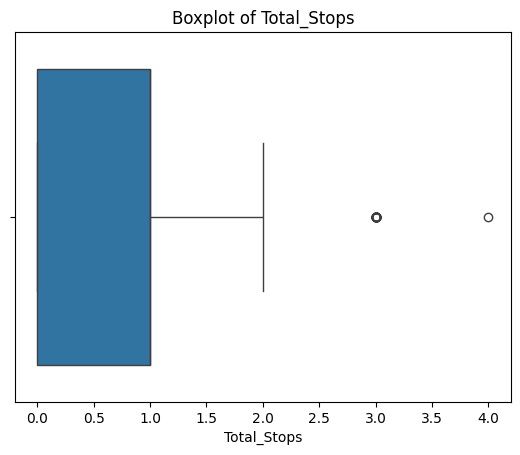

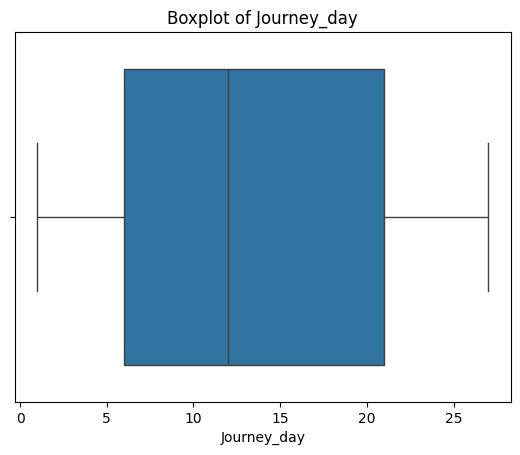

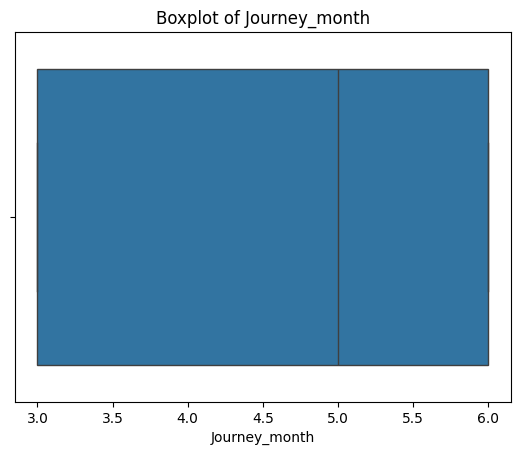

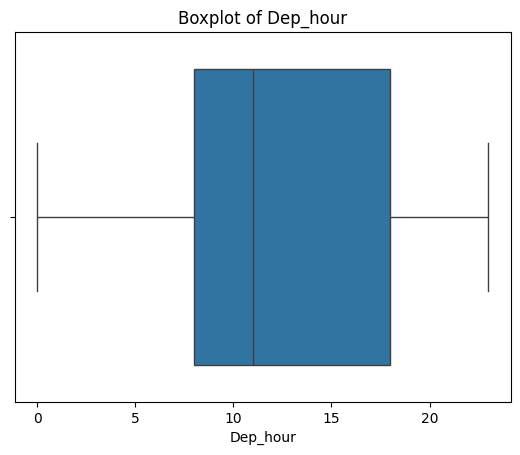

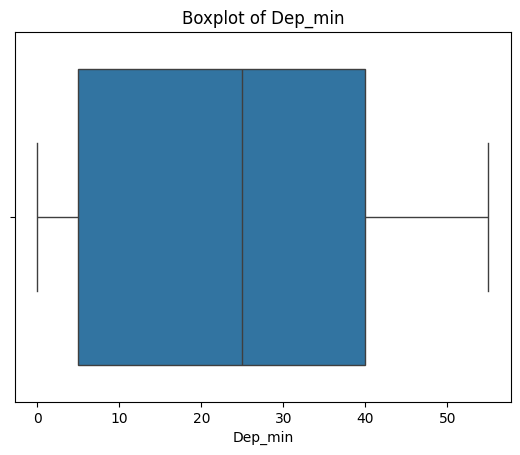

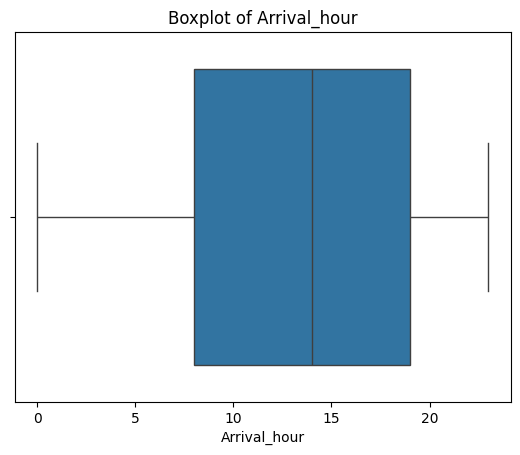

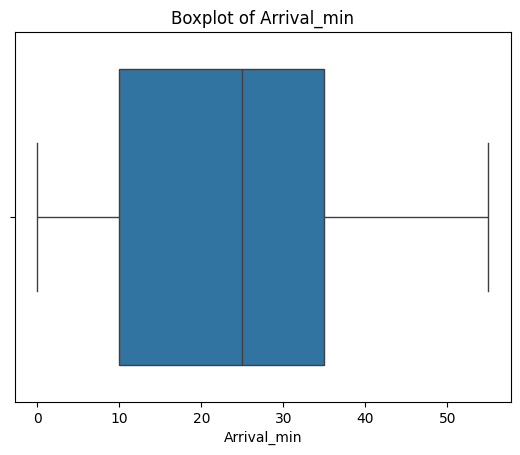

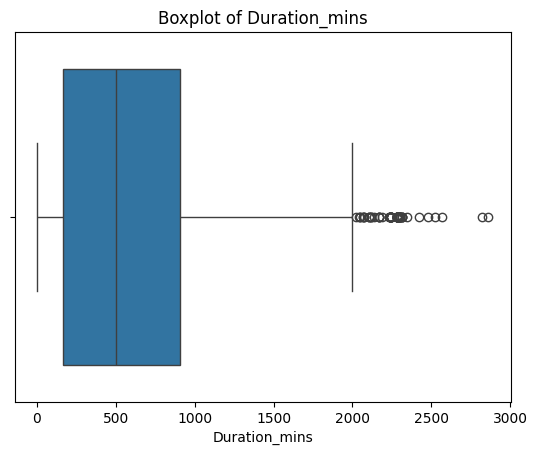

In [34]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Outliers were analyzed using boxplots and IQR method.
However, they were not removed because they represent genuine variations in flight prices (e.g., premium flights, long durations).
Tree-based models like Random Forest are robust to outliers, hence no removal was performed.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [36]:
# Splitting data into x and y
X = data.drop("Price", axis=1)
y = data["Price"]

In [37]:
## Converting categorical columns into numerical columns...(Perfroming OneHot Encoding)
X = pd.get_dummies(X, columns=["Airline", "Source", "Destination"], drop_first=True, dtype=int)

In [38]:
X

,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_mins,Airline_Air India,Airline_GoAir,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,24,3,22,20,1,10,170.0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1,5,5,50,13,15,445.0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,2,9,6,9,25,4,25,1140.0,0,0,...,0,0,1,0,0,1,0,0,0,0
3,1,12,5,18,5,23,30,325.0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,1,1,3,16,50,21,35,285.0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,9,4,19,55,22,25,150.0,0,0,...,0,0,0,1,0,0,0,0,0,0
10679,0,27,4,20,45,23,20,155.0,1,0,...,0,0,0,1,0,0,0,0,0,0
10680,0,27,4,8,20,11,20,180.0,0,0,...,0,0,0,0,0,0,1,0,0,0
10681,0,1,3,11,30,14,10,160.0,0,0,...,0,0,0,0,0,0,0,0,0,1


### Model Building 

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred=model.predict(X_test)
y_pred

array([14546.1866191 ,  4536.30368424,  4779.97483618, ...,
       11875.62994525, 11312.76316897, 11587.38796872], shape=(2093,))

### Model Evaluation

In [43]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [75]:
r2_lr=r2_score(y_test,y_pred)

In [76]:
r2_lr

0.5838081325633981

##### Linear Regression was used as a baseline model and achieved an R² score of around 0.58

### Decision Tree 

In [45]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [46]:
y_pred_dt = dt.predict(X_test)

In [47]:
r2_score(y_test,y_pred_dt)

0.7146170646423705

We got R2 score as 71.46% for the base Decision Tree Regressor

In [48]:
## Checking Overfitting...
print("Train Score:", dt.score(X_train, y_train))
print("Test Score:", dt.score(X_test, y_test))

Train Score: 0.9697961300999993
Test Score: 0.7146170646423705


##### Decision Tree gave better performance than Linear Regression but showed signs of overfitting, as training accuracy was very high compared to test accuracy.

### Hyper parameter Tuning--->GridSearchCV

In [49]:
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [50]:
grid.best_params_

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}

In [51]:
dt1=DecisionTreeRegressor(max_depth=15, min_samples_leaf=1, min_samples_split=10)

In [52]:
dt1.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=15, min_samples_split=10)

In [53]:
y_pred_dt1 = dt1.predict(X_test)

In [77]:
r2_dt=r2_score(y_test,y_pred_dt1)
r2_dt

0.7888877052836705

##### After applying GridSearchCV for hyperparameter tuning, the Decision Tree model achieved an R² score of 78.8%, showing a significant improvement over the default model.

### Random Forest 

In [55]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [56]:
y_pred_rf = rf.predict(X_test)

In [57]:
r2_score(y_test,y_pred_rf)

0.8133811655649046

##### Random Forest (Default) = 81.33%

In [58]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [59]:
grid_rf.best_params_

{'max_depth': 15,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}

In [60]:
rf1 = RandomForestRegressor(max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=500)
rf1.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_split=5, n_estimators=500)

In [61]:
y_pred_rf1=rf1.predict(X_test)

In [81]:
r2_rf=r2_score(y_test,y_pred_rf1)
r2_rf

0.8393737126674733

##### R2 score of Random Forest using hyper parameter tuning is 83.93%

### XGBoost

In [82]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [64]:
from xgboost import XGBRegressor

In [65]:
xgb=XGBRegressor(random_state=42)

In [66]:
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
y_pred_xgb=xgb.predict(X_test)

In [68]:
r2_score(y_test,y_pred_xgb)

0.8373496532440186

In [69]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid=params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Params:", grid_xgb.best_params_)

Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


In [70]:
grid_xgb.best_params_

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

In [71]:
xgb1=XGBRegressor(learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.8)
xgb1.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [72]:
y_pred_xgb1=xgb1.predict(X_test)

In [83]:
r2_xgb=r2_score(y_test,y_pred_xgb1)
r2_xgb

0.8414948582649231

##### R2 score of XgBoost using hyer parameter tuning is 84.149%

#### Comparison Table of Regression models 

In [84]:
model_performance=pd.DataFrame({"Model":[
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"],"R2 Score":[r2_lr,
                           r2_dt,
                           r2_rf,
                           r2_xgb
                          ]
                               })

In [85]:
model_performance

,Model,R2 Score
0,Linear Regression,0.583808
1,Decision Tree,0.788888
2,Random Forest,0.839374
3,XGBoost,0.841495


In [87]:
### Keeping the Best Model on the top...(From descending to Ascending)
model_performance=model_performance.sort_values(by="R2 Score", ascending=False)
model_performance 

,Model,R2 Score
3,XGBoost,0.841495
2,Random Forest,0.839374
1,Decision Tree,0.788888
0,Linear Regression,0.583808


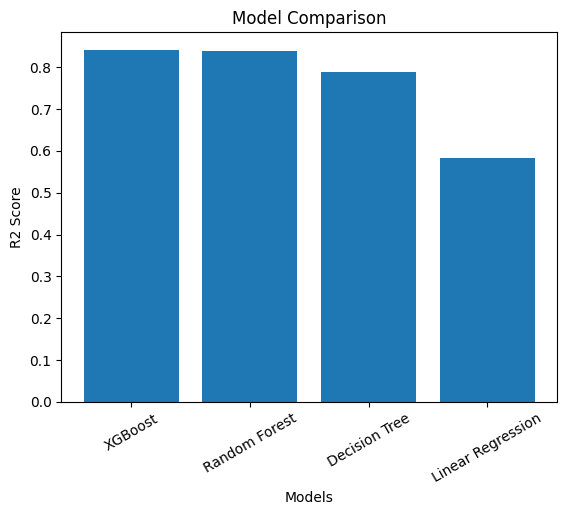

In [88]:
plt.figure()
plt.bar(model_performance["Model"], model_performance["R2 Score"])
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

#### A comparison of multiple regression models was performed using R² score.   
#### Random Forest and XGBoost achieved the highest performance (~84%), while Linear Regression showed lower performance...

In [117]:
sample_index = 100

sample = X.iloc[[sample_index]]

predicted_price = xgb1.predict(sample)

print("Actual Price:", y.iloc[sample_index])
print("Predicted Price:", predicted_price[0])

Actual Price: 14781
Predicted Price: 12393.546


In [119]:
for i in range(5):
    sample = X.iloc[[i]]
    print(f"\nSample {i}")
    print("Actual:", y.iloc[i])
    print("Predicted:", xgb1.predict(sample)[0])


Sample 0
Actual: 3897
Predicted: 5612.7295

Sample 1
Actual: 7662
Predicted: 8579.993

Sample 2
Actual: 13882
Predicted: 13049.903

Sample 3
Actual: 6218
Predicted: 6196.6357

Sample 4
Actual: 13302
Predicted: 13713.928
